# 03 - E5 Baseline de segmentacion sagital 2D

**Objetivo:** construir un primer baseline simple y defendible de segmentacion sagital 2D sobre SPIDER, sin usar nnU-Net todavia.

Este notebook valida el flujo completo:

- carga de candidatos filtrados en E4;
- seleccion de slices sagitales del eje 2;
- normalizacion p1-p99;
- conversion de mascara a binaria;
- entrenamiento liviano de una U-Net 2D simple;
- inferencia, metricas y visualizacion;
- exportacion de evidencias reproducibles.

**Fuera de alcance:** segmentacion multiclase, spike axial, nnU-Net, MONAI avanzado e integracion backend.

## 1. Instalacion e importacion de dependencias

In [1]:
!pip -q install SimpleITK scikit-image tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 10.4 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import json
import random
import warnings

import SimpleITK as sitk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.transform import resize
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("SimpleITK:", sitk.Version())
print("Dispositivo:", DEVICE)

PyTorch: 2.11.0+cpu
SimpleITK: SimpleITK Version: 2.5.5 (ITK 5.4)
Compiled: May 12 2026 17:19:38

Dispositivo: cpu


## 2. Montaje de Drive y definicion de rutas

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
DATASET_ROOT = Path("/content/drive/MyDrive/PFI_MVP/data/SPIDER")
PREPROCESS_ROOT = Path("/content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento")
BASELINE_ROOT = Path("/content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital")
FIGURES_ROOT = Path("/content/drive/MyDrive/PFI_MVP/figures")
DOCS_ROOT = Path("/content/drive/MyDrive/PFI_MVP/docs")

for path in [BASELINE_ROOT, FIGURES_ROOT, DOCS_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

CANDIDATES_CSV = PREPROCESS_ROOT / "E4_baseline_candidates_no_space.csv"

print("DATASET_ROOT:", DATASET_ROOT)
print("PREPROCESS_ROOT:", PREPROCESS_ROOT)
print("BASELINE_ROOT:", BASELINE_ROOT)
print("FIGURES_ROOT:", FIGURES_ROOT)
print("DOCS_ROOT:", DOCS_ROOT)
print("CANDIDATES_CSV:", CANDIDATES_CSV)

DATASET_ROOT: /content/drive/MyDrive/PFI_MVP/data/SPIDER
PREPROCESS_ROOT: /content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento
BASELINE_ROOT: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital
FIGURES_ROOT: /content/drive/MyDrive/PFI_MVP/figures
DOCS_ROOT: /content/drive/MyDrive/PFI_MVP/docs
CANDIDATES_CSV: /content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento/E4_baseline_candidates_no_space.csv


## 3. Carga de candidatos validos

In [5]:
candidates_df = pd.read_csv(CANDIDATES_CSV)

print("Columnas:", list(candidates_df.columns))
print("Candidatos totales:", len(candidates_df))
display(candidates_df.head())

Columnas: ['case_id', 'image_path', 'mask_path', 'image_shape_zyx', 'mask_shape_zyx', 'same_shape', 'image_spacing_xyz', 'mask_spacing_xyz', 'same_spacing', 'image_origin_xyz', 'mask_origin_xyz', 'same_origin', 'image_direction', 'mask_direction', 'same_direction', 'image_dtype', 'mask_dtype', 'image_min', 'image_max', 'image_mean', 'image_p01', 'image_p05', 'image_p50', 'image_p95', 'image_p99', 'mask_unique_labels', 'mask_label_voxel_counts', 'mask_nonzero_voxels']
Candidatos totales: 406


,case_id,image_path,mask_path,image_shape_zyx,mask_shape_zyx,same_shape,image_spacing_xyz,mask_spacing_xyz,same_spacing,image_origin_xyz,...,image_max,image_mean,image_p01,image_p05,image_p50,image_p95,image_p99,mask_unique_labels,mask_label_voxel_counts,mask_nonzero_voxels
0,100_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(797, 492, 21)","(797, 492, 21)",True,"(4.389695960744017, 0.6305175528662943, 0.3879...","(4.389695960744017, 0.6305175528662943, 0.3879...",True,"(-44.77723154001997, -122.57786786661, -106.77...",...,3096.0,323.473495,-1000.0,-1000.0,119.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 100, 201, 202, 203...","{""0"": 7882170, ""1"": 39628, ""2"": 41281, ""3"": 39...",352434
1,100_t2,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(797, 492, 21)","(797, 492, 21)",True,"(4.389695960744017, 0.6305175528662943, 0.3879...","(4.389695960744017, 0.6305175528662943, 0.3879...",True,"(-44.77723154001997, -122.57786786661, -106.77...",...,3096.0,284.090210,-1000.0,-1000.0,-206.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 100, 201, 202, 203...","{""0"": 7882170, ""1"": 39628, ""2"": 41281, ""3"": 39...",352434
2,101_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(298, 320, 17)","(298, 320, 17)",True,"(4.788765599257572, 0.812500000003979, 0.87628...","(4.788765599257572, 0.812500000003979, 0.87628...",True,"(-67.28904018297013, -124.77837801043, -103.82...",...,3096.0,286.182632,-1000.0,-1000.0,-96.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 100, 201, 202, 203, 204,...","{""0"": 1485954, ""1"": 17797, ""2"": 19492, ""3"": 18...",135166
3,101_t2,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(352, 384, 17)","(352, 384, 17)",True,"(4.7905672101450465, 0.6770833134684295, 0.740...","(4.7905672101450465, 0.6770833134684295, 0.740...",True,"(-67.28904013221916, -124.77837419574, -103.95...",...,3096.0,96.152873,-1000.0,-1000.0,-451.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 100, 201, 202, 203, 204,...","{""0"": 2106060, ""1"": 25305, ""2"": 27649, ""3"": 26...",191796
4,104_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(320, 320, 15)","(320, 320, 15)",True,"(4.8000000544956425, 0.875, 0.875)","(4.8000000544956425, 0.875, 0.875)",True,"(-1500.868783405839, -123.65617370674, -102.07...",...,3096.0,416.166051,-1000.0,-1000.0,86.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 7, 100, 201, 202, 203, 2...","{""0"": 1424313, ""1"": 13002, ""2"": 13903, ""3"": 14...",111687


In [6]:
# Parametros editables para el experimento baseline.
MODALITY_FILTER = "t1"  # opciones sugeridas: "t1", "t2", "both"
N_CASES = 20
SAGITTAL_AXIS = 2
TARGET_SIZE = (256, 256)
BATCH_SIZE = 4
EPOCHS = 5
LEARNING_RATE = 1e-3

def infer_case_modality(row):
    text = " ".join(str(v).lower() for v in row.values)
    if "t2" in text:
        return "t2"
    if "t1" in text:
        return "t1"
    return "unknown"


work_df = candidates_df.copy()
if "modality" not in work_df.columns:
    work_df["modality"] = work_df.apply(infer_case_modality, axis=1)

if MODALITY_FILTER != "both":
    filtered_df = work_df[work_df["modality"].str.lower().eq(MODALITY_FILTER)].copy()
else:
    filtered_df = work_df.copy()

if len(filtered_df) == 0:
    raise RuntimeError(f"No hay candidatos para MODALITY_FILTER={MODALITY_FILTER}. Revisar columnas del CSV.")

selected_df = filtered_df.sample(n=min(N_CASES, len(filtered_df)), random_state=SEED).reset_index(drop=True)

print("Filtro de modalidad:", MODALITY_FILTER)
print("Candidatos luego del filtro:", len(filtered_df))
print("Casos seleccionados para baseline:", len(selected_df))
display(selected_df.head())

Filtro de modalidad: t1
Candidatos luego del filtro: 196
Casos seleccionados para baseline: 20


,case_id,image_path,mask_path,image_shape_zyx,mask_shape_zyx,same_shape,image_spacing_xyz,mask_spacing_xyz,same_spacing,image_origin_xyz,...,image_mean,image_p01,image_p05,image_p50,image_p95,image_p99,mask_unique_labels,mask_label_voxel_counts,mask_nonzero_voxels,modality
0,34_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(17, 512, 512)","(17, 512, 512)",True,"(0.5859375, 0.5859375, 3.29999995231625)","(0.5859375, 0.5859375, 3.29999995231625)",True,"(25.310411453247, -173.97094345166, 208.794188...",...,67.792228,0.0,2.0,46.0,237.0,381.0,"[0, 1, 2, 3, 4, 5, 6, 7, 100, 201, 202, 203, 2...","{""0"": 4067496, ""1"": 45569, ""2"": 46824, ""3"": 47...",388952,t1
1,237_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(611, 646, 18)","(611, 646, 18)",True,"(4.397158886379771, 0.47702580399344185, 0.504...","(4.397158886379771, 0.47702580399344185, 0.504...",True,"(-35.357652670789285, -105.48043042480317, -15...",...,223.040949,-1000.0,-1000.0,-42.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 100, 201, 202, 203, 204,...","{""0"": 6853402, ""1"": 29378, ""2"": 28073, ""3"": 28...",251306,t1
2,11_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(590, 512, 21)","(590, 512, 21)",True,"(3.312444001646348, 0.5859375000028706, 0.5109...","(3.312444001646348, 0.5859375000028706, 0.5109...",True,"(-48.262890541576496, -151.08433532714844, -52...",...,577.450562,-1000.0,-1000.0,405.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 100, 201, 202, 203...","{""0"": 5904536, ""1"": 49436, ""2"": 48522, ""3"": 46...",439144,t1
3,192_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(448, 448, 24)","(448, 448, 24)",True,"(3.2999548400246894, 0.625, 0.6252388405966087)","(3.2999548400246903, 0.6250000000000001, 0.625...",True,"(-33.95211536991131, -100.35483169555, -118.04...",...,440.976977,-1000.0,-1000.0,212.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 100, 201, 202, 203, 204,...","{""0"": 4583424, ""1"": 34950, ""2"": 35448, ""3"": 34...",233472,t1
4,52_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(17, 512, 512)","(17, 512, 512)",True,"(0.5859375, 0.5859375, 3.299999961969196)","(0.5859375, 0.5859375, 3.299999961969196)",True,"(40.290493751358, -169.61259079053, 354.605962...",...,182.957843,0.0,2.0,174.0,375.0,451.0,"[0, 1, 2, 3, 4, 5, 6, 7, 100, 201, 202, 203, 2...","{""0"": 4051205, ""1"": 45458, ""2"": 51726, ""3"": 53...",405243,t1


## 4. Funciones de lectura y preprocesamiento

In [8]:
def resolve_path(value):
    path = Path(str(value))
    if path.exists():
        return path
    return Path(str(value).replace("/content/drive/MyDrive", "/content/drive/MyDrive"))


def get_case_paths(row):
    image_candidates = ["image_path", "source_image_path", "image", "img_path"]
    mask_candidates = ["mask_path", "source_mask_path", "mask", "seg_path"]

    image_path = None
    mask_path = None

    for column in image_candidates:
        if column in row and pd.notna(row[column]):
            image_path = resolve_path(row[column])
            break

    for column in mask_candidates:
        if column in row and pd.notna(row[column]):
            mask_path = resolve_path(row[column])
            break

    if image_path is None or mask_path is None:
        raise ValueError("No se encontraron columnas de path para imagen/mascara. Revisar CSV de E4.")

    return image_path, mask_path


def read_mha(path: Path):
    itk_image = sitk.ReadImage(str(path))
    array = sitk.GetArrayFromImage(itk_image)
    return itk_image, array


def robust_percentile_normalize(image_array, p_low=1, p_high=99, eps=1e-8):
    image_float = image_array.astype(np.float32)
    low, high = np.percentile(image_float, [p_low, p_high])
    clipped = np.clip(image_float, low, high)
    if np.isclose(high, low):
        normalized = np.zeros_like(clipped, dtype=np.float32)
    else:
        normalized = (clipped - low) / (high - low + eps)
    return normalized.astype(np.float32)


def binarize_mask(mask_array):
    return (mask_array > 0).astype(np.float32)


def representative_slice_index(mask_array, axis=2):
    if np.count_nonzero(mask_array) == 0:
        return int(mask_array.shape[axis] // 2)
    reduce_axes = tuple(ax for ax in range(mask_array.ndim) if ax != axis)
    area_by_slice = np.sum(mask_array > 0, axis=reduce_axes)
    return int(np.argmax(area_by_slice))


def take_slice(array, axis, index):
    return np.take(array, indices=index, axis=axis)


def resize_slice(array_2d, target_size=TARGET_SIZE, order=1):
    return resize(
        array_2d,
        output_shape=target_size,
        order=order,
        preserve_range=True,
        anti_aliasing=(order != 0),
    ).astype(np.float32)


def preprocess_case(row, axis=SAGITTAL_AXIS, target_size=TARGET_SIZE):
    image_path, mask_path = get_case_paths(row)
    itk_image, image = read_mha(image_path)
    itk_mask, mask = read_mha(mask_path)

    if image.shape != mask.shape:
        raise ValueError(f"Shape incompatible: image={image.shape}, mask={mask.shape}")

    image_norm = robust_percentile_normalize(image)
    mask_bin = binarize_mask(mask)
    slice_index = representative_slice_index(mask_bin, axis=axis)

    image_slice = take_slice(image_norm, axis, slice_index)
    mask_slice = take_slice(mask_bin, axis, slice_index)

    image_slice = resize_slice(image_slice, target_size=target_size, order=1)
    mask_slice = resize_slice(mask_slice, target_size=target_size, order=0)
    mask_slice = (mask_slice > 0.5).astype(np.float32)

    case_id = row["case_id"] if "case_id" in row else image_path.stem

    return {
        "case_id": str(case_id),
        "image": image_slice[None, ...].astype(np.float32),
        "mask": mask_slice[None, ...].astype(np.float32),
        "slice_index": int(slice_index),
        "spacing": tuple(float(x) for x in itk_image.GetSpacing()),
        "source_image_path": str(image_path),
        "source_mask_path": str(mask_path),
    }

**Decision de tamano comun:** para este baseline se redimensiona cada slice a `256x256`.

Esta decision simplifica el entrenamiento 2D inicial y mantiene bajo el costo computacional. En etapas posteriores puede reemplazarse por pad/crop fisicamente mas controlado o por entrenamiento 3D/2.5D.

In [9]:
preview_case = preprocess_case(selected_df.iloc[0])
print("case_id:", preview_case["case_id"])
print("image tensor shape:", preview_case["image"].shape, preview_case["image"].dtype)
print("mask tensor shape:", preview_case["mask"].shape, preview_case["mask"].dtype)
print("mask unique values:", np.unique(preview_case["mask"]))
print("slice_index:", preview_case["slice_index"])

case_id: 34_t1
image tensor shape: (1, 256, 256) float32
mask tensor shape: (1, 256, 256) float32
mask unique values: [0. 1.]
slice_index: 326


## 5. Dataset 2D para entrenamiento

In [10]:
class SpiderSagittalSliceDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe.reset_index(drop=True)
        self.cache = {}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        if index not in self.cache:
            self.cache[index] = preprocess_case(self.dataframe.iloc[index])

        item = self.cache[index]
        image = torch.from_numpy(item["image"]).float()
        mask = torch.from_numpy(item["mask"]).float()

        return {
            "image": image,
            "mask": mask,
            "case_id": item["case_id"],
            "slice_index": item["slice_index"],
            "source_image_path": item["source_image_path"],
            "source_mask_path": item["source_mask_path"],
        }


dataset = SpiderSagittalSliceDataset(selected_df)

val_size = max(1, int(round(0.2 * len(dataset))))
train_size = len(dataset) - val_size
if train_size < 1:
    raise RuntimeError("Se necesita al menos un caso de entrenamiento.")

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print("Train cases:", len(train_dataset))
print("Validation cases:", len(val_dataset))
print("Batch image shape:", batch["image"].shape)
print("Batch mask shape:", batch["mask"].shape)
print("Batch mask unique values:", torch.unique(batch["mask"]))

Train cases: 16
Validation cases: 4
Batch image shape: torch.Size([4, 1, 256, 256])
Batch mask shape: torch.Size([4, 1, 256, 256])
Batch mask unique values: tensor([0., 1.])


## 6. Modelo baseline: U-Net 2D simple en PyTorch

In [11]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SimpleUNet2D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=16):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base_channels)
        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_channels * 4, base_channels * 8)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4)
        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2)
        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels)

        self.out = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)


def dice_coefficient_from_logits(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    intersection = torch.sum(preds * targets, dim=(1, 2, 3))
    denominator = torch.sum(preds, dim=(1, 2, 3)) + torch.sum(targets, dim=(1, 2, 3))
    return ((2.0 * intersection + eps) / (denominator + eps)).mean()


def iou_from_logits(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    intersection = torch.sum(preds * targets, dim=(1, 2, 3))
    union = torch.sum(((preds + targets) > 0).float(), dim=(1, 2, 3))
    return ((intersection + eps) / (union + eps)).mean()


class DiceBCELoss(nn.Module):
    def __init__(self, dice_weight=1.0, bce_weight=1.0):
        super().__init__()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets, eps=1e-7):
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        intersection = torch.sum(probs * targets, dim=(1, 2, 3))
        denominator = torch.sum(probs, dim=(1, 2, 3)) + torch.sum(targets, dim=(1, 2, 3))
        dice_loss = 1.0 - ((2.0 * intersection + eps) / (denominator + eps)).mean()
        return self.dice_weight * dice_loss + self.bce_weight * bce_loss


model = SimpleUNet2D().to(DEVICE)
criterion = DiceBCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

test_logits = model(batch["image"].to(DEVICE))
print("Salida del modelo:", test_logits.shape)

Salida del modelo: torch.Size([4, 1, 256, 256])


## 7. Entrenamiento liviano

In [12]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    losses = []
    dices = []
    ious = []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for batch in loader:
            images = batch["image"].to(DEVICE)
            masks = batch["mask"].to(DEVICE)

            logits = model(images)
            loss = criterion(logits, masks)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            losses.append(float(loss.detach().cpu()))
            dices.append(float(dice_coefficient_from_logits(logits.detach(), masks).cpu()))
            ious.append(float(iou_from_logits(logits.detach(), masks).cpu()))

    return {
        "loss": float(np.mean(losses)),
        "dice": float(np.mean(dices)),
        "iou": float(np.mean(ious)),
    }


history = []
for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(model, train_loader, optimizer=optimizer)
    val_metrics = run_epoch(model, val_loader, optimizer=None)

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_dice": train_metrics["dice"],
        "train_iou": train_metrics["iou"],
        "val_loss": val_metrics["loss"],
        "val_dice": val_metrics["dice"],
        "val_iou": val_metrics["iou"],
    }
    history.append(row)
    print(row)

history_df = pd.DataFrame(history)
history_csv_path = BASELINE_ROOT / "E5_training_history.csv"
history_df.to_csv(history_csv_path, index=False)

print("History CSV:", history_csv_path)
display(history_df)

{'epoch': 1, 'train_loss': 1.4102785885334015, 'train_dice': 0.4122335612773895, 'train_iou': 0.2747642397880554, 'val_loss': 1.5164573192596436, 'val_dice': 0.23635954037308693, 'val_iou': 0.1343536376953125}
{'epoch': 2, 'train_loss': 1.3346068263053894, 'train_dice': 0.4664520174264908, 'train_iou': 0.3172340616583824, 'val_loss': 1.5465212762355804, 'val_dice': 0.23635954037308693, 'val_iou': 0.1343536376953125}
{'epoch': 3, 'train_loss': 1.3038343489170074, 'train_dice': 0.4756452143192291, 'train_iou': 0.32580988109111786, 'val_loss': 1.589540034532547, 'val_dice': 0.23635954037308693, 'val_iou': 0.1343536376953125}
{'epoch': 4, 'train_loss': 1.2777832448482513, 'train_dice': 0.4854065775871277, 'train_iou': 0.3337622135877609, 'val_loss': 1.645867645740509, 'val_dice': 0.23635954037308693, 'val_iou': 0.1343536376953125}
{'epoch': 5, 'train_loss': 1.2320158779621124, 'train_dice': 0.5052939057350159, 'train_iou': 0.34996645152568817, 'val_loss': 1.7324314713478088, 'val_dice': 0.

,epoch,train_loss,train_dice,train_iou,val_loss,val_dice,val_iou
0,1,1.410279,0.412234,0.274764,1.516457,0.23636,0.134354
1,2,1.334607,0.466452,0.317234,1.546521,0.23636,0.134354
2,3,1.303834,0.475645,0.325810,1.589540,0.23636,0.134354
3,4,1.277783,0.485407,0.333762,1.645868,0.23636,0.134354
4,5,1.232016,0.505294,0.349966,1.732431,0.23636,0.134354


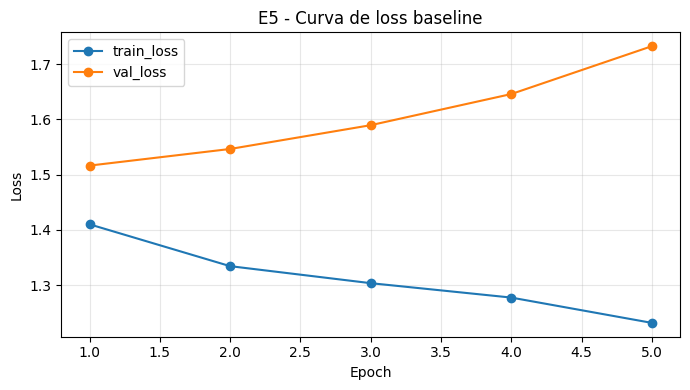

PNG curva de loss: /content/drive/MyDrive/PFI_MVP/figures/E5_training_loss_curve.png


In [13]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
ax.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("E5 - Curva de loss baseline")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

loss_png_path = FIGURES_ROOT / "E5_training_loss_curve.png"
fig.savefig(loss_png_path, dpi=150, bbox_inches="tight")
plt.show()

print("PNG curva de loss:", loss_png_path)

## 8. Evaluacion y visualizacion

In [14]:
def predict_batch(model, batch):
    model.eval()
    with torch.no_grad():
        images = batch["image"].to(DEVICE)
        masks = batch["mask"].to(DEVICE)
        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
    return logits.cpu(), probs.cpu(), preds.cpu(), masks.cpu()


metrics_rows = []
saved_example = None

model.eval()
for batch in val_loader:
    logits, probs, preds, masks = predict_batch(model, batch)

    dice = float(dice_coefficient_from_logits(logits, masks).cpu())
    iou = float(iou_from_logits(logits, masks).cpu())

    row = {
        "case_id": batch["case_id"][0],
        "slice_index": int(batch["slice_index"][0]),
        "dice": dice,
        "iou": iou,
        "source_image_path": batch["source_image_path"][0],
        "source_mask_path": batch["source_mask_path"][0],
    }
    metrics_rows.append(row)

    if saved_example is None:
        saved_example = {
            "image": batch["image"][0, 0].numpy(),
            "mask": masks[0, 0].numpy(),
            "pred": preds[0, 0].numpy(),
            "prob": probs[0, 0].numpy(),
            "case_id": batch["case_id"][0],
            "slice_index": int(batch["slice_index"][0]),
        }

metrics_df = pd.DataFrame(metrics_rows)
if metrics_df[["dice", "iou"]].isna().any().any():
    raise RuntimeError("Se detectaron metricas NaN.")

metrics_csv_path = BASELINE_ROOT / "E5_baseline_metrics.csv"
metrics_df.to_csv(metrics_csv_path, index=False)

print("Metricas CSV:", metrics_csv_path)
display(metrics_df)
print("Dice promedio:", metrics_df["dice"].mean())
print("IoU promedio:", metrics_df["iou"].mean())

Metricas CSV: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_baseline_metrics.csv


,case_id,slice_index,dice,iou,source_image_path,source_mask_path
0,88_t1,8,0.261437,0.150375,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...
1,86_t1,11,0.236549,0.134140,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...
2,3_t1,8,0.261045,0.150116,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...
3,67_t1,11,0.186407,0.102783,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...


Dice promedio: 0.23635954037308693
IoU promedio: 0.1343536376953125


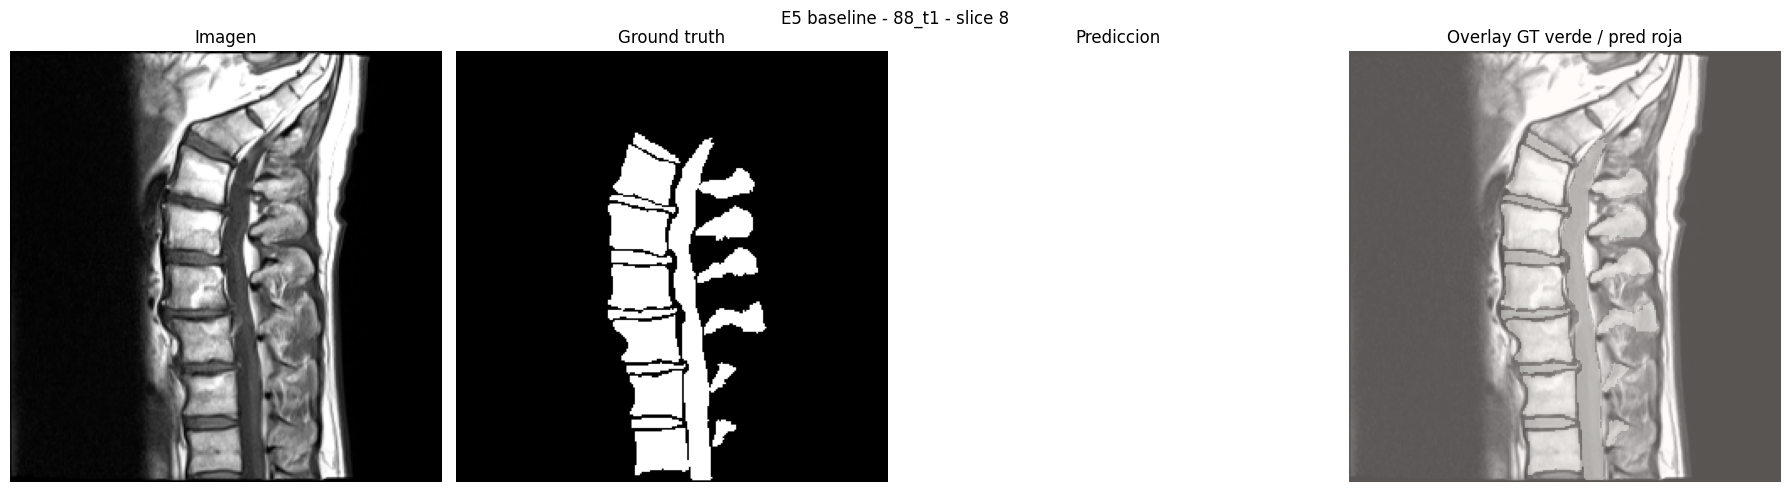

PNG prediccion/GT/overlay: /content/drive/MyDrive/PFI_MVP/figures/E5_baseline_prediction_88_t1.png


In [15]:
image = saved_example["image"]
mask = saved_example["mask"]
pred = saved_example["pred"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(image, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Imagen")
axes[1].imshow(mask, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Ground truth")
axes[2].imshow(pred, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Prediccion")
axes[3].imshow(image, cmap="gray", vmin=0, vmax=1)
axes[3].imshow(np.ma.masked_where(mask == 0, mask), cmap="Greens", alpha=0.45)
axes[3].imshow(np.ma.masked_where(pred == 0, pred), cmap="Reds", alpha=0.35)
axes[3].set_title("Overlay GT verde / pred roja")

for ax in axes:
    ax.axis("off")

fig.suptitle(f"E5 baseline - {saved_example['case_id']} - slice {saved_example['slice_index']}")
fig.tight_layout()

prediction_png_path = FIGURES_ROOT / f"E5_baseline_prediction_{saved_example['case_id']}.png"
fig.savefig(prediction_png_path, dpi=150, bbox_inches="tight")
plt.show()

print("PNG prediccion/GT/overlay:", prediction_png_path)

In [16]:
model_path = BASELINE_ROOT / "E5_simple_unet2d_baseline.pt"
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "history": history,
        "target_size": TARGET_SIZE,
        "sagittal_axis": SAGITTAL_AXIS,
        "modality_filter": MODALITY_FILTER,
        "n_cases": len(selected_df),
    },
    model_path,
)

print("Modelo exportado:", model_path)

Modelo exportado: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_simple_unet2d_baseline.pt


## 9. Validaciones finales

In [17]:
validation_report = {
    "candidate_csv_exists": CANDIDATES_CSV.exists(),
    "selected_cases": int(len(selected_df)),
    "train_cases": int(len(train_dataset)),
    "val_cases": int(len(val_dataset)),
    "tensor_image_shape": list(batch["image"].shape),
    "tensor_mask_shape": list(batch["mask"].shape),
    "masks_are_binary": bool(set(torch.unique(batch["mask"]).cpu().numpy().tolist()).issubset({0.0, 1.0})),
    "metrics_have_nan": bool(metrics_df[["dice", "iou"]].isna().any().any()),
    "metrics_csv": str(metrics_csv_path),
    "history_csv": str(history_csv_path),
    "prediction_png": str(prediction_png_path),
    "model_path": str(model_path),
}

validation_report_path = BASELINE_ROOT / "E5_validation_report.json"
validation_report_path.write_text(json.dumps(validation_report, indent=2), encoding="utf-8")

print(json.dumps(validation_report, indent=2))

{
  "candidate_csv_exists": true,
  "selected_cases": 20,
  "train_cases": 16,
  "val_cases": 4,
  "tensor_image_shape": [
    1,
    1,
    256,
    256
  ],
  "tensor_mask_shape": [
    1,
    1,
    256,
    256
  ],
  "masks_are_binary": true,
  "metrics_have_nan": false,
  "metrics_csv": "/content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_baseline_metrics.csv",
  "history_csv": "/content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_training_history.csv",
  "prediction_png": "/content/drive/MyDrive/PFI_MVP/figures/E5_baseline_prediction_88_t1.png",
  "model_path": "/content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_simple_unet2d_baseline.pt"
}


## 10. Conclusion tecnica

In [18]:
conclusion_md = f"""# Conclusion tecnica - E5 Baseline de segmentacion sagital 2D

## Objetivo

Se construyo un primer baseline binario 2D sobre slices sagitales del dataset SPIDER para validar el pipeline de entrenamiento, inferencia, metricas y visualizacion.

## Configuracion

- Fuente de candidatos: `{CANDIDATES_CSV}`
- Casos seleccionados: {len(selected_df)}
- Filtro de modalidad: `{MODALITY_FILTER}`
- Eje sagital usado: {SAGITTAL_AXIS}
- Tamano comun de slice: {TARGET_SIZE}
- Epocas: {EPOCHS}
- Modelo: U-Net 2D simple en PyTorch
- Segmentacion: binaria (`mask > 0`)

## Resultados

- Dice promedio validacion: {metrics_df['dice'].mean():.4f}
- IoU promedio validacion: {metrics_df['iou'].mean():.4f}

## Evidencias exportadas

- Metricas por caso: `{metrics_csv_path}`
- Historial de entrenamiento: `{history_csv_path}`
- Curva de loss: `{loss_png_path}`
- Visualizacion imagen / ground truth / prediccion / overlay: `{prediction_png_path}`
- Modelo PyTorch: `{model_path}`
- Reporte de validacion: `{validation_report_path}`

## Interpretacion

Este baseline no busca rendimiento final. Su objetivo es demostrar que el flujo completo de datos, entrenamiento, inferencia, metricas y visualizacion funciona sobre un subconjunto pequeno y controlado.

## Limitaciones

- Subconjunto pequeno de casos.
- Segmentacion binaria.
- Seleccion de un unico slice sagital por volumen.
- Redimensionado simple a tamano comun.
- Sin segmentacion multiclase.
- Sin nnU-Net todavia.
- Sin spike axial.
- Sin integracion backend.
- Exclusion inicial de casos `t2_SPACE` mediante el CSV generado en E4.

## Criterio de aceptacion

El notebook carga casos candidatos desde E4, genera slices sagitales normalizados, convierte mascaras a binarias, entrena un baseline simple, calcula Dice e IoU, exporta metricas y genera una visualizacion comparando imagen, mascara real y prediccion.
"""

conclusion_path = DOCS_ROOT / "E5_baseline_segmentacion_sagital_conclusion.md"
conclusion_path.write_text(conclusion_md, encoding="utf-8")

print(conclusion_md)
print("Conclusion Markdown:", conclusion_path)

# Conclusion tecnica - E5 Baseline de segmentacion sagital 2D

## Objetivo

Se construyo un primer baseline binario 2D sobre slices sagitales del dataset SPIDER para validar el pipeline de entrenamiento, inferencia, metricas y visualizacion.

## Configuracion

- Fuente de candidatos: `/content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento/E4_baseline_candidates_no_space.csv`
- Casos seleccionados: 20
- Filtro de modalidad: `t1`
- Eje sagital usado: 2
- Tamano comun de slice: (256, 256)
- Epocas: 5
- Modelo: U-Net 2D simple en PyTorch
- Segmentacion: binaria (`mask > 0`)

## Resultados

- Dice promedio validacion: 0.2364
- IoU promedio validacion: 0.1344

## Evidencias exportadas

- Metricas por caso: `/content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_baseline_metrics.csv`
- Historial de entrenamiento: `/content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_training_history.csv`
- Curva de loss: `/content/drive/MyDrive/PFI_MVP/figures/E5_training_loss_curve.png`
-